In [7]:
import numpy as np
import matplotlib.pyplot as plt
XYZ = np.load("XYZViolinsToAlign.npy")
Nm = 256
Ns = XYZ.shape[0] - Nm
print(XYZ[:Ns,:])
num_chunks = Nm//8

[[-1.42304582  0.27191611  0.59502509]
 [-0.40284209  0.20328603  1.39354948]
 [-0.79512475 -1.13327745 -0.34588396]
 [ 0.22833641 -1.21273196  0.58048181]
 [ 0.30233666 -0.1249976  -1.3567643 ]
 [ 1.20469062 -0.02883976 -0.42296336]
 [-0.5936289   1.37979489 -0.77348841]
 [ 0.40434655  1.39087096  0.17808407]
 [-0.00433666  0.13819868  0.19146694]
 [-0.43453647  1.02167347  0.3694546 ]
 [ 0.94038852  0.7918406  -0.93210184]
 [ 0.63467184  0.02635627  0.46331957]
 [ 0.05830498 -0.06401188  0.14858638]]


In [8]:
def plotToAlignAndAligned(xyz_toalign, xyz_aligned, ns):
    fig = plt.figure(figsize=(14, 6))

    # Define colors for chunks to see alignment better
    # Use plt.get_cmap instead of cm.get_cmap to avoid deprecation warning
    cmap = plt.get_cmap('tab20', num_chunks)

    # Plot Original
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_title("Before Rotation")
    ax1.scatter(xyz_toalign[:ns, 0], xyz_toalign[:ns, 1], xyz_toalign[:ns, 2], c='k', marker='x', label='Sources', alpha=0.5)

    # Plot chunks with colors
    for i in range(num_chunks):
        c_mics = xyz_toalign[ns + i*8 : ns + (i+1)*8, :]
        ax1.scatter(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), marker='o', s=20)
        # Draw line through chunk to show direction
        # Simple line between start and end of chunk for visualization
        ax1.plot(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), alpha=0.5)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')

    # Plot Rotated
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_title("After Rotation")
    ax2.scatter(xyz_aligned[:ns, 0], xyz_aligned[:ns, 1], xyz_aligned[:ns, 2], c='k', marker='x', label='Sources', alpha=0.5)

    for i in range(num_chunks):
        c_mics = xyz_aligned[ns + i*8 : ns + (i+1)*8, :]
        ax2.scatter(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), marker='o', s=20)
        ax2.plot(c_mics[:, 0], c_mics[:, 1], c_mics[:, 2], color=cmap(i), alpha=0.5)

    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')

    plt.tight_layout()
    plt.show()


In [9]:
def align_pointclouds(XYZ_ref, XYZ_est, ind_to_align):
    """
    Align a point cloud with a reference one, using the described in the following communication :
    'A solution for the best rotation to relate two sets of vectors', Kabsch, Acta Cryst 1976.
    Inputs : 
    - XYZ_ref : (Nref,3) array, lines are reference points to align.
    - XYZ_est : (Nest,3) array, lines are positions to align (Nest>=Nref).
    - ind_to_align : (Nref,1) array, indices corresponding to the points in XYZ_est to align with XYZ_est.
    Outputs : 
    - XYZ_ref_centered : (Nref, 3) array, lines are centered positions of the reference points.
    - XYZ_est : : (Nest, 3) array, lines are centered positions of the aligned points.
    """
    # Start by centering point clouds
    center_ref = XYZ_ref.mean(axis = 0)
    XYZ_ref_centered = XYZ_ref - center_ref

    center_est = XYZ_est[ind_to_align,:].mean(axis = 0)
    XYZ_est_centered = XYZ_est - center_est

    # Compute covariance between point clouds
    S_ref_est = XYZ_est_centered[ind_to_align,:].T @ XYZ_ref_centered
    
    # Perform covariance's svd
    u, s, v = np.linalg.svd(S_ref_est)
    # find rotation's sign
    e = np.eye(3)
    e[-1, -1] = np.sign(s.prod())
    # compute Rotation matrix (adjust sign with e)
    rotation = (v.T @ e @ u.T).T
    # Perform rotation on centered cloud to align
    XYZ_est_aligned = XYZ_est_centered @rotation
    
    return XYZ_ref_centered, XYZ_est_aligned

In [10]:
index_ref = np.array([27*8, 12*8, 0, 31*8 + 7, 28*8, 20*8+2 , 2*8, 1*8, 12*8 + 7, 29*8+4, 24*8+3])+Ns
XYZ_ref = np.array([[ 50,  30,  53], 
                    [-67, -39, -21],
                    [-49,  54,  45],
                    [ 28, -50, -29],
                    [ 24, -61,  42],
                    [  0, -60, -13],
                    [ 50,  25, -22],
                    [-65, -41,  53],
                    [-66,  40,  -5],
                    [-23,   0, -29],
                    [ -4,  -4,  60]], dtype = float) * 1e-2

# Sort XYZ_ref wr to index_ref sorted order
sorted_indices = np.argsort(index_ref)
index_ref = np.array(index_ref)[sorted_indices]
XYZ_ref = XYZ_ref[sorted_indices]

for i,j in enumerate(index_ref):
    print(f"Mic {j-Ns}: {XYZ_ref[i]}")

Mic 0: [-0.49  0.54  0.45]
Mic 8: [-0.65 -0.41  0.53]
Mic 16: [ 0.5   0.25 -0.22]
Mic 96: [-0.67 -0.39 -0.21]
Mic 103: [-0.66  0.4  -0.05]
Mic 162: [ 0.   -0.6  -0.13]
Mic 195: [-0.04 -0.04  0.6 ]
Mic 216: [0.5  0.3  0.53]
Mic 224: [ 0.24 -0.61  0.42]
Mic 236: [-0.23  0.   -0.29]
Mic 255: [ 0.28 -0.5  -0.29]


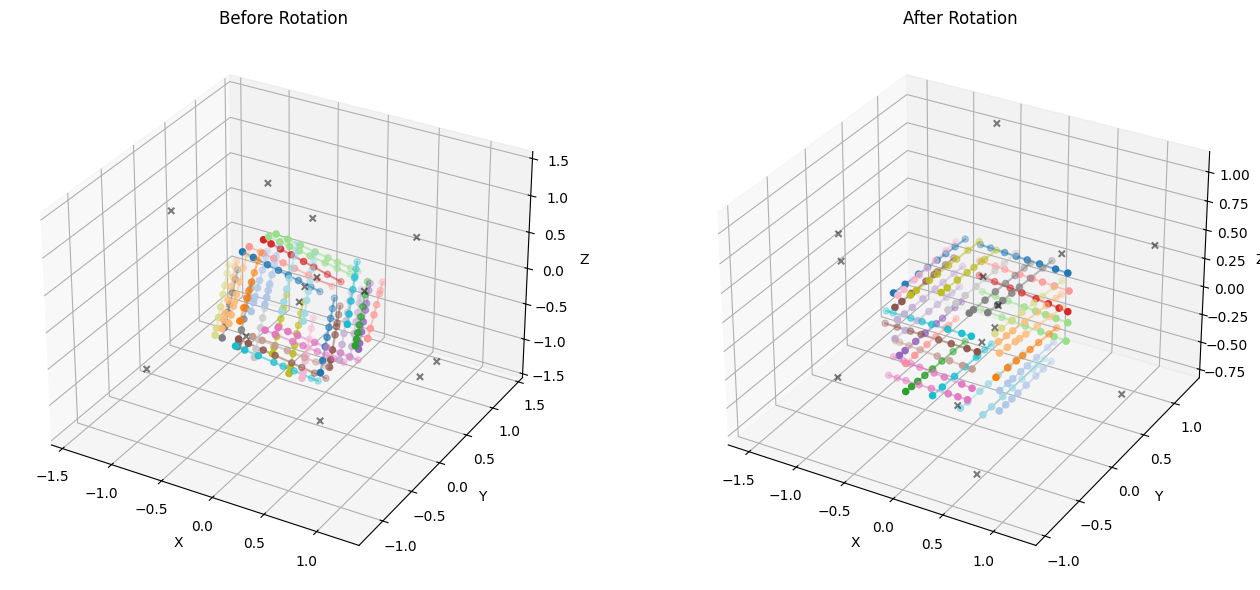

In [11]:
XYZ_ref_centered, XYZViolinsAligned = align_pointclouds(XYZ_ref, XYZ, index_ref)
plotToAlignAndAligned(XYZ, XYZViolinsAligned, Ns)
np.save("XYZViolinsAligned.npy", XYZViolinsAligned)